In [1]:
# %pip install pmdarima
# %pip install dtaidistance
# %pip install tslearn
# %pip install pymannkendall
# %pip install pyhomogeneity
# %pip install pybfast

In [2]:
#Será rodado separado
# from pybfast import BFASTMonitor

#from sklearn.impute import IterativeImputer

In [3]:
import os
import re
from pathlib import Path

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyhomogeneity as hg
import pymannkendall as mk
import rasterio
import statsmodels.api as sm
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from pmdarima import auto_arima
from rasterio.warp import transform
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator
from scipy.spatial.distance import euclidean
from scipy.stats import theilslopes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_log_error, mean_squared_log_error, accuracy_score, classification_report, confusion_matrix
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from wcpms import *
from wtss import *

2026-08-05 03:36:59.506109: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 03:36:59.585814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-05 03:37:01.502977: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
point_file = '/home/jovyan/Disciplinas/Data_Science/10_ts/ts2.gpkg'

In [5]:
input_dir = "/home/jovyan/Disciplinas/Data_Science/10_ts/imgs"

lon = -45.6303
lat = -20.7074

/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20250728_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20250914_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20251101_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260117_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260322_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260509_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260712_NDVI.tif
        date  value                                               file
0 2025-07-28   7482  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
1 2025-09-14   5406  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
2 2025-11-01   2130  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
3 2026-01-17   1203  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
4 2026-03-22   2429  /home/jovyan/Disciplinas/Data_Scienc

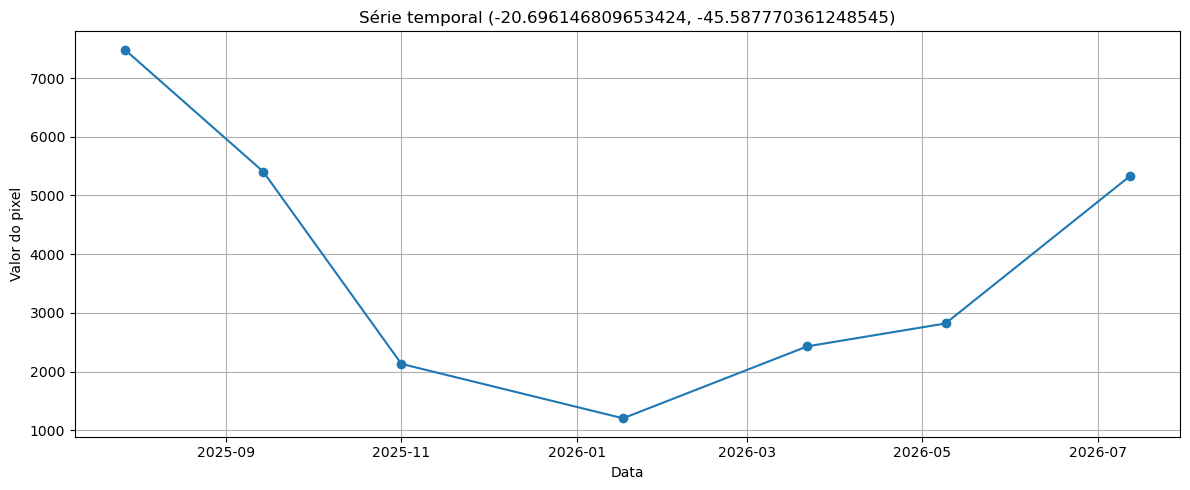

In [50]:
series = []

for tif in sorted(Path(input_dir).rglob("*.tif")):
        print(tif)
        with rasterio.open(tif) as src:
            if src.crs and src.crs.to_epsg() != 4326:
                xs, ys = transform(
                    "EPSG:4326",
                    src.crs,
                    [lon],
                    [lat]
                )
                x, y = xs[0], ys[0]
            else:
                x, y = lon, lat

            value = next(src.sample([(x, y)]))[0]

        m = re.search(r'(\d{8})', tif.name)
        if m:
            date = pd.to_datetime(m.group(1), format="%Y%m%d")
        else:
            date = tif.name

        series.append({
            "date": date,
            "value": value,
            "file": str(tif)
        })

df = pd.DataFrame(series)

if len(df) == 0:
    raise RuntimeError("Nenhum dado encontrado.")

df = df.sort_values("date")

print(df)

# Gráfico
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["value"], marker="o")
plt.xlabel("Data")
plt.ylabel("Valor do pixel")
plt.title(f"Série temporal ({lat}, {lon})")
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
serie1 = pd.Series(
    data=df["value"].values,
    index=pd.to_datetime(df["date"]),
    name="value"
)

print(serie1)

date
2025-07-28    7482
2025-09-14    5406
2025-11-01    2130
2026-01-17    1203
2026-03-22    2429
2026-05-09    2819
2026-07-12    5327
Name: value, dtype: int16


/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20250728_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20250914_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20251101_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260117_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260322_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260509_NDVI.tif
/home/jovyan/Disciplinas/Data_Science/10_ts/imgs/S2-16D_V2_030027_20260712_NDVI.tif
        date  value                                               file
0 2025-07-28   4651  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
1 2025-09-14   4763  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
2 2025-11-01   6815  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
3 2026-01-17   6281  /home/jovyan/Disciplinas/Data_Science/10_ts/im...
4 2026-03-22   7493  /home/jovyan/Disciplinas/Data_Scienc

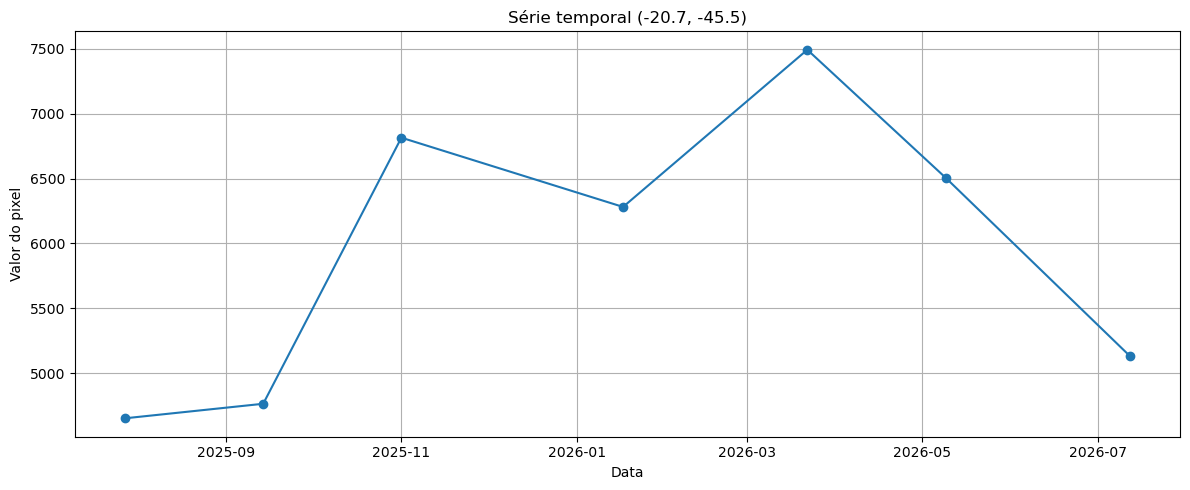

date
2025-07-28    4651
2025-09-14    4763
2025-11-01    6815
2026-01-17    6281
2026-03-22    7493
2026-05-09    6507
2026-07-12    5132
Name: value, dtype: int16


In [52]:
lon = -45.5
lat = -20.7

series = []

for tif in sorted(Path(input_dir).rglob("*.tif")):
        print(tif)
        with rasterio.open(tif) as src:
            if src.crs and src.crs.to_epsg() != 4326:
                xs, ys = transform(
                    "EPSG:4326",
                    src.crs,
                    [lon],
                    [lat]
                )
                x, y = xs[0], ys[0]
            else:
                x, y = lon, lat

            value = next(src.sample([(x, y)]))[0]

        m = re.search(r'(\d{8})', tif.name)
        if m:
            date = pd.to_datetime(m.group(1), format="%Y%m%d")
        else:
            date = tif.name

        series.append({
            "date": date,
            "value": value,
            "file": str(tif)
        })

df = pd.DataFrame(series)

if len(df) == 0:
    raise RuntimeError("Nenhum dado encontrado.")

df = df.sort_values("date")

print(df)

# Gráfico
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["value"], marker="o")
plt.xlabel("Data")
plt.ylabel("Valor do pixel")
plt.title(f"Série temporal ({lat}, {lon})")
plt.grid(True)
plt.tight_layout()
plt.show()

serie2 = pd.Series(
    data=df["value"].values,
    index=pd.to_datetime(df["date"]),
    name="value"
)

print(serie2)

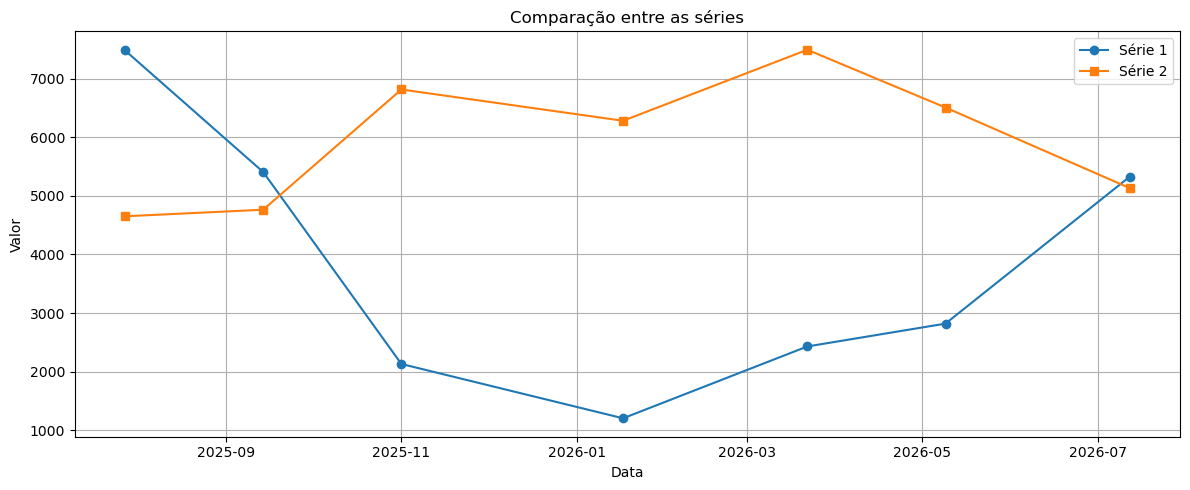

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(serie1.index, serie1.values, label="Série 1", marker="o")
plt.plot(serie2.index, serie2.values, label="Série 2", marker="s")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Distancias

In [54]:
dist = euclidean(serie1, serie1)
dist

0.0

In [55]:
dist = euclidean(serie1, serie2)
dist

9769.686996009646

0.0
Pares alinhados: 7


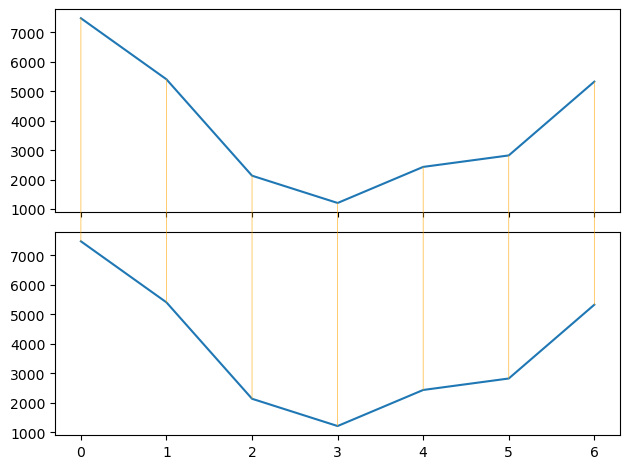

In [56]:
distance, paths = dtw.warping_paths(serie1.values, serie1.values)

best_path = dtw.best_path(paths)

print(distance)
print("Pares alinhados:", len(best_path))

dtwvis.plot_warping(serie1.values, serie1.values, best_path)
plt.show()

7909.907711218886
Pares alinhados: 9


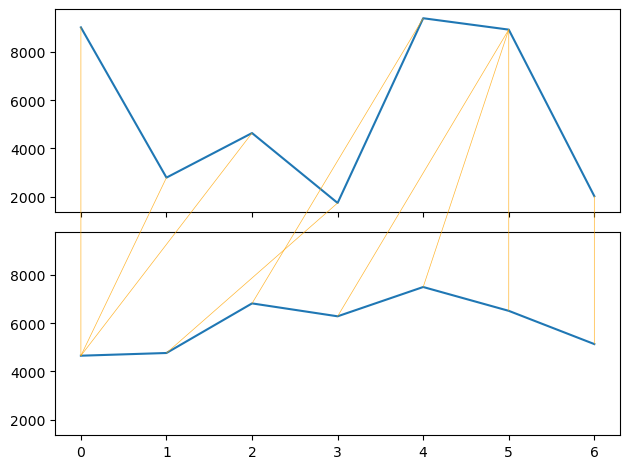

In [13]:
distance, paths = dtw.warping_paths(serie1.values, serie2.values)

best_path = dtw.best_path(paths)

print(distance)
print("Pares alinhados:", len(best_path))

dtwvis.plot_warping(serie1.values, serie2.values, best_path)
plt.show()

## Load

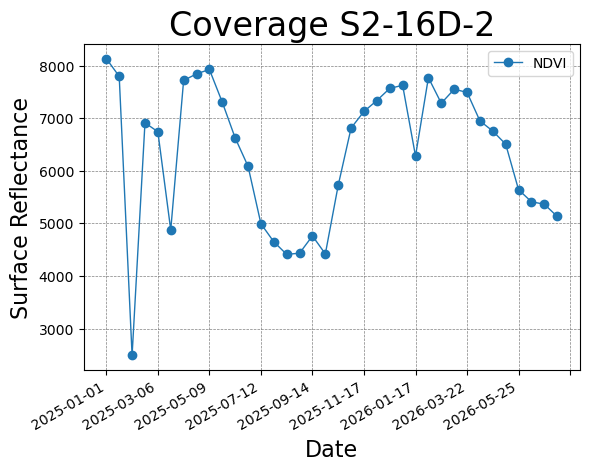

In [57]:
service = WTSS('https://data.inpe.br/bdc/wtss/v4/')
coverage = service['S2-16D-2']
ts = coverage.ts(attributes=('NDVI'),
                 latitude=lat, longitude=lon,
                 start_date='2025-01-01', end_date='2026-12-31')
ts.plot()

In [59]:
lon

-45.5

In [60]:
lat

-20.7

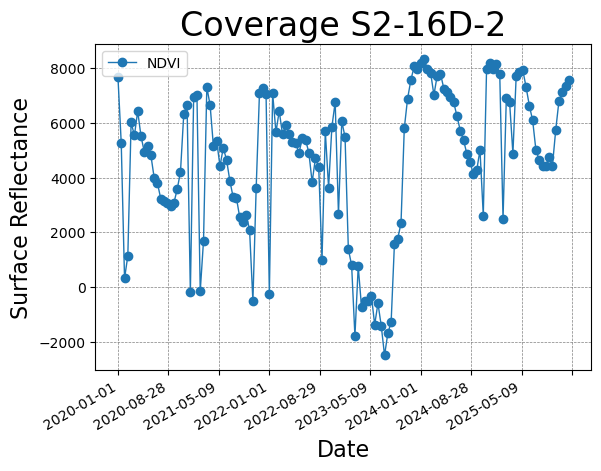

In [58]:
service = WTSS('https://data.inpe.br/bdc/wtss/v4/')
coverage = service['S2-16D-2']
ts = coverage.ts(attributes=('NDVI'),
                 latitude=lat, longitude=lon,
                 start_date='2020-01-01', end_date='2025-12-31')
ts.plot()

In [61]:
gdf = gpd.read_file(point_file, layer="ts")

print(gdf)
print(gdf.crs)

       class                     geometry
0       agua  POINT (-45.64765 -20.70176)
1       agua  POINT (-45.65449 -20.70993)
2       agua  POINT (-45.67474 -20.72049)
3       agua  POINT (-45.63813 -20.68722)
4       agua  POINT (-45.62348 -20.70872)
5       agua  POINT (-45.67213 -20.69659)
6       agua  POINT (-45.59474 -20.68904)
7       agua   POINT (-45.65632 -20.7319)
8       agua  POINT (-45.69606 -20.71637)
9       agua  POINT (-45.69577 -20.73681)
10      pivo   POINT (-45.63668 -20.7137)
11      pivo  POINT (-45.62857 -20.70752)
12      pivo  POINT (-45.68259 -20.70071)
13      pivo  POINT (-45.68962 -20.69933)
14      pivo  POINT (-45.70023 -20.69479)
15      pivo  POINT (-45.69615 -20.69456)
16      pivo  POINT (-45.68302 -20.70634)
17      pivo  POINT (-45.69084 -20.70251)
18      pivo  POINT (-45.63168 -20.70817)
19      pivo  POINT (-45.63723 -20.71147)
20  floresta  POINT (-45.62772 -20.75279)
21  floresta  POINT (-45.62285 -20.75086)
22  floresta  POINT (-45.61287 -20

In [62]:
gdf["ts"] = None
gdf

,class,geometry,ts
0,agua,POINT (-45.64765 -20.70176),None
1,agua,POINT (-45.65449 -20.70993),None
2,agua,POINT (-45.67474 -20.72049),None
3,agua,POINT (-45.63813 -20.68722),None
4,agua,POINT (-45.62348 -20.70872),None
5,agua,POINT (-45.67213 -20.69659),None
6,agua,POINT (-45.59474 -20.68904),None
7,agua,POINT (-45.65632 -20.7319),None
8,agua,POINT (-45.69606 -20.71637),None
9,agua,POINT (-45.69577 -20.73681),None


In [63]:
for idx, row in gdf.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    ts = coverage.ts(attributes=('NDVI'),
                 latitude=lat, longitude=lon,
                 start_date='2020-01-01', end_date='2025-12-31')
    
    serie = pd.Series(
        data=ts.NDVI,
        index=pd.to_datetime(ts.timeline),
        name="NDVI"
    )
    gdf.at[idx, "ts"] = serie
gdf    

,class,geometry,ts
0,agua,POINT (-45.64765 -20.70176),2020-01-01 -5941 2020-01-17 -1284 2020-02-...
1,agua,POINT (-45.65449 -20.70993),2020-01-01 198 2020-01-17 -2867 2020-02-...
2,agua,POINT (-45.67474 -20.72049),2020-01-01 -1409 2020-01-17 -204 2020-02-...
3,agua,POINT (-45.63813 -20.68722),2020-01-01 17 2020-01-17 877 2020-02-...
4,agua,POINT (-45.62348 -20.70872),2020-01-01 -7287 2020-01-17 -7128 2020-02-...
5,agua,POINT (-45.67213 -20.69659),2020-01-01 -473 2020-01-17 171 2020-02-...
6,agua,POINT (-45.59474 -20.68904),2020-01-01 -6007 2020-01-17 -5940 2020-02-...
7,agua,POINT (-45.65632 -20.7319),2020-01-01 6640 2020-01-17 2263 2020-02-...
8,agua,POINT (-45.69606 -20.71637),2020-01-01 896 2020-01-17 -8352 2020-02-...
9,agua,POINT (-45.69577 -20.73681),2020-01-01 -2107 2020-01-17 -2520 2020-02-...


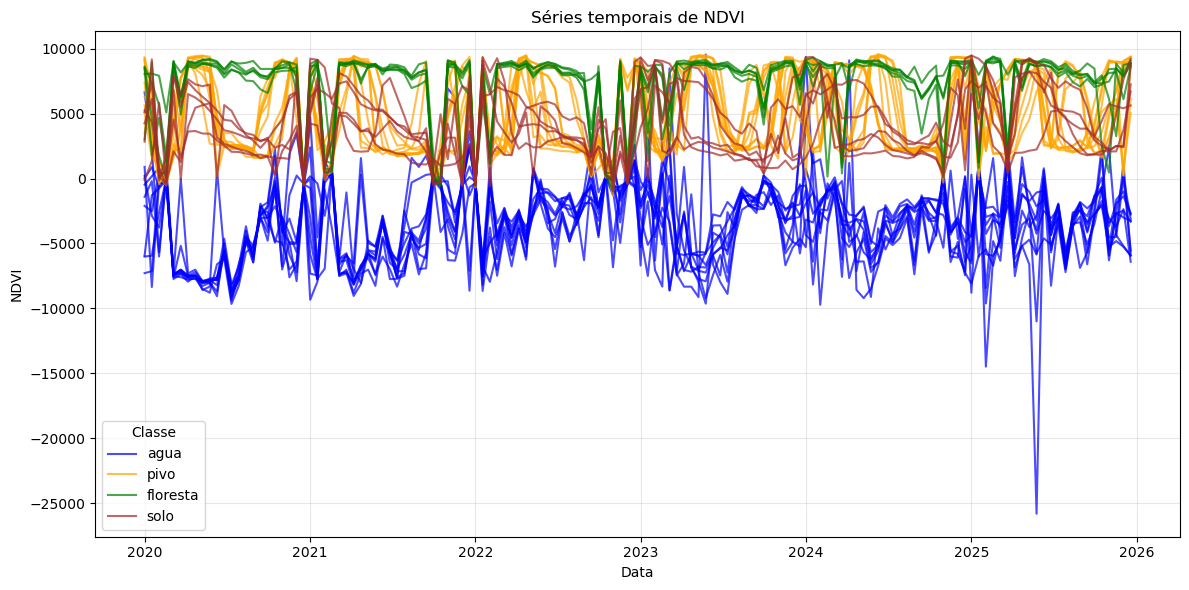

In [64]:
colors = {
    "agua": "blue",
    "pivo": "orange",
    "floresta": "green",
    "solo": "brown"
}

plt.figure(figsize=(12, 6))

legend = set()

for _, row in gdf.iterrows():

    if row["ts"] is None:
        continue

    label = row["class"] if row["class"] not in legend else None
    legend.add(row["class"])

    plt.plot(
        row["ts"].index,
        row["ts"].values,
        color=colors[row["class"]],
        alpha=0.7,
        linewidth=1.5,
        label=label
    )

plt.xlabel("Data")
plt.ylabel("NDVI")
plt.title("Séries temporais de NDVI")
plt.grid(True, alpha=0.3)
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

## Split

In [65]:
linha = gdf.iloc[11]
linha['ts']

2020-01-01    9087
2020-01-17    3130
2020-02-02    -328
2020-02-18    1392
2020-03-05    6957
              ... 
2025-10-16    2168
2025-11-01    4979
2025-11-17    6682
2025-12-03    9062
2025-12-19    9370
Name: NDVI, Length: 138, dtype: int64

In [66]:
treino = linha['ts'].loc[:'2024-12-31']
validacao = linha['ts'].loc['2025-01-01':]
print(treino)
print()
print(validacao)

2020-01-01    9087
2020-01-17    3130
2020-02-02    -328
2020-02-18    1392
2020-03-05    6957
              ... 
2024-10-15    3190
2024-10-31     149
2024-11-16    9317
2024-12-02    9354
2024-12-18    9228
Name: NDVI, Length: 115, dtype: int64

2025-01-01    9169
2025-01-17    4669
2025-02-02    2551
2025-02-18    6665
2025-03-06    7226
2025-03-22    8365
2025-04-07    9089
2025-04-23    8990
2025-05-09    9060
2025-05-25    8457
2025-06-10    2535
2025-06-26    2515
2025-07-12    8253
2025-07-28    9040
2025-08-13    8744
2025-08-29    7561
2025-09-14    2710
2025-09-30    1981
2025-10-16    2168
2025-11-01    4979
2025-11-17    6682
2025-12-03    9062
2025-12-19    9370
Name: NDVI, dtype: int64


## Gap-filling

In [67]:
treino_nan = treino.copy()

np.random.seed(42)

n_nan = 40

indices_nan = np.random.choice(
    treino_nan.index,
    size=n_nan,
    replace=False
)

treino_nan.loc[indices_nan] = np.nan

In [70]:
print(treino_nan.values)

[  nan 3130. -328. 1392.   nan 3659. 8716. 8448. 7956.   nan   nan   nan
   nan 2558. 2514.   nan 1605. 1731.   nan 3771. 8555. 9291.   nan 7718.
 8906.  520.   nan 7163.   nan 9122.   nan   nan 8715.   nan 4051. 3381.
   nan 2315. 2413. 2918.   nan   36.   nan 7107.   nan   nan -279.   nan
 2676. 2026. 2590. 7045. 8892.   nan 8614. 8217. 7885. 6902. 3477. 3310.
 2029. 2245.   nan 2232.   80.   nan   nan   nan 9175.   nan   nan 2073.
   nan 8215. 8912. 8689. 8751. 8657.   nan 7053. 4303.   nan 2496.   nan
   nan 3026. 2296. 3418. 7533. 9226. 9149. 7102. 3887.   nan   nan 4874.
 8859. 8736. 8737. 8627.   nan 6650. 4138. 2782. 2284.   nan 2205. 1966.
   nan   nan 3190.  149.   nan   nan 9228.]


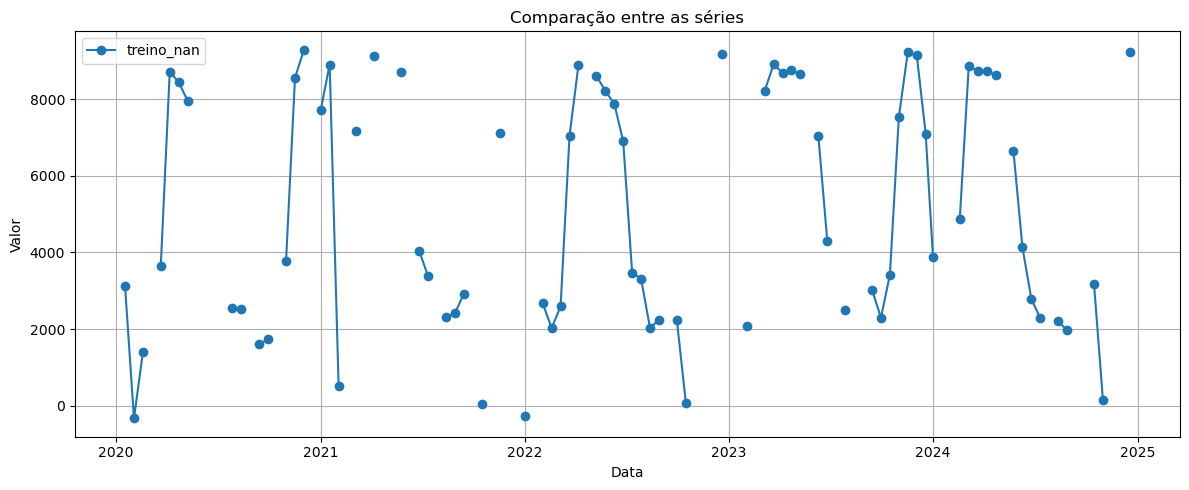

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

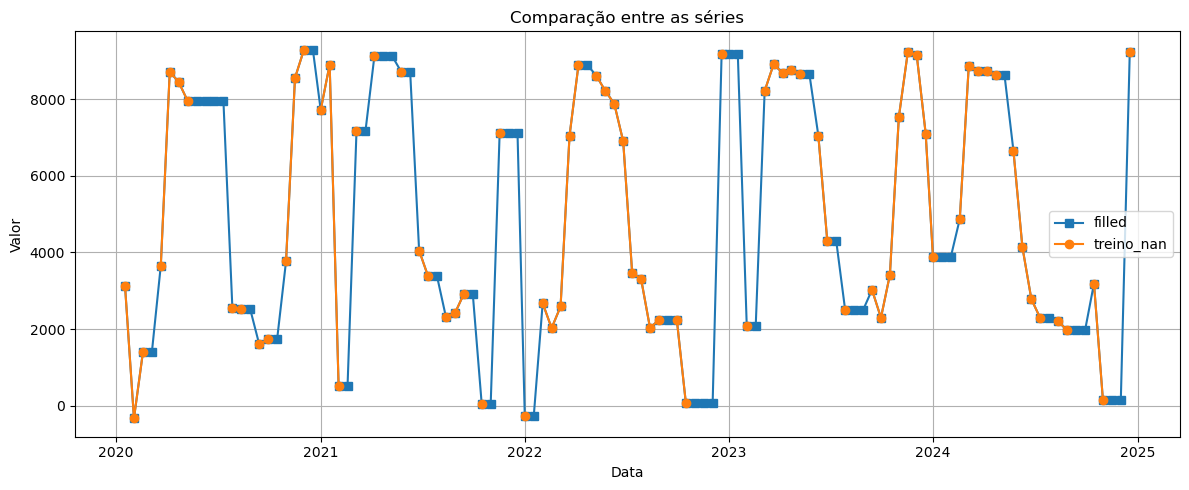

In [72]:
serie_filled = treino_nan.ffill()

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

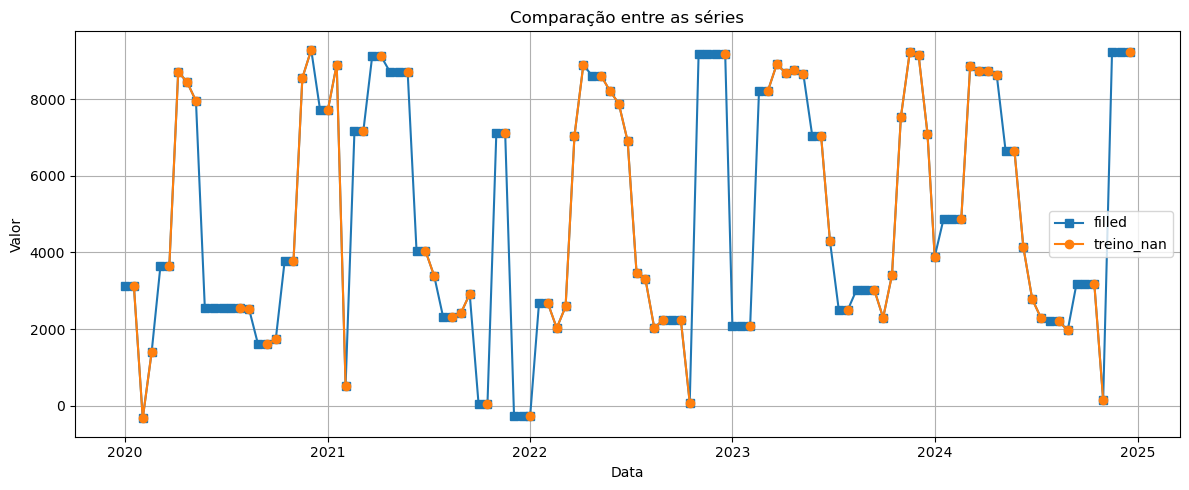

In [74]:
serie_filled = treino_nan.bfill()

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

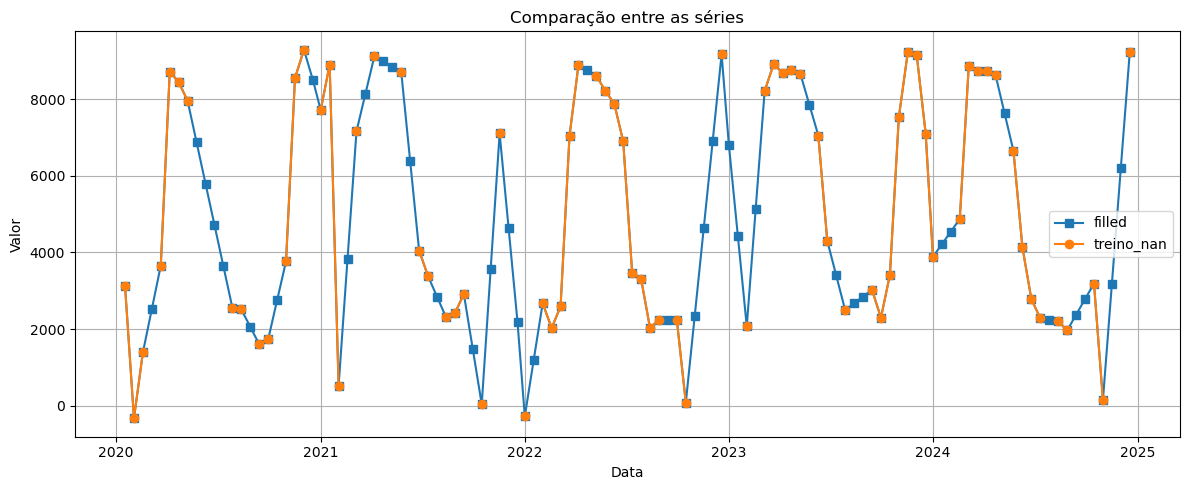

In [25]:
serie_filled = treino_nan.interpolate(method="linear")

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

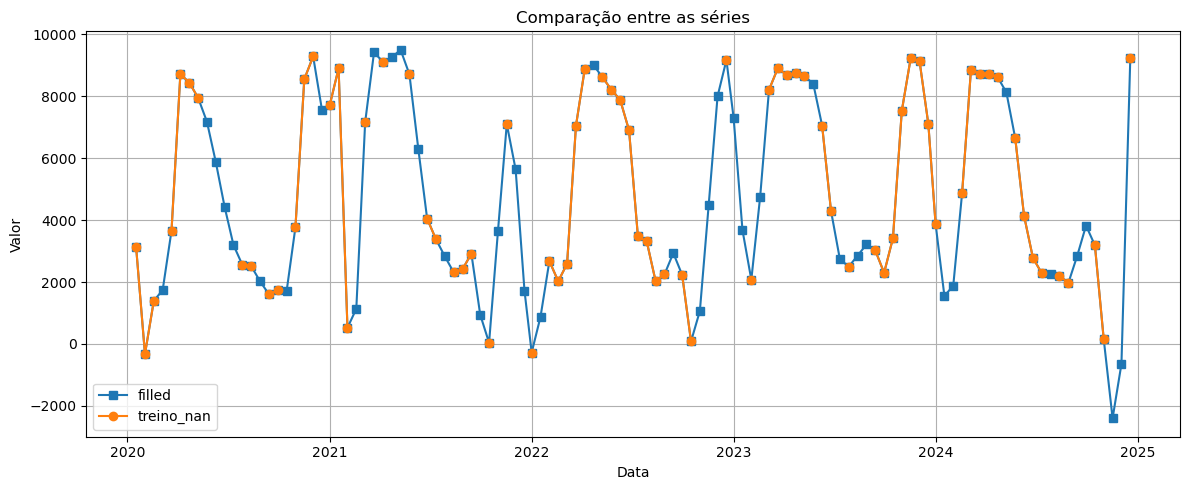

In [26]:
serie_filled = treino_nan.interpolate(method="spline", order=3)

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

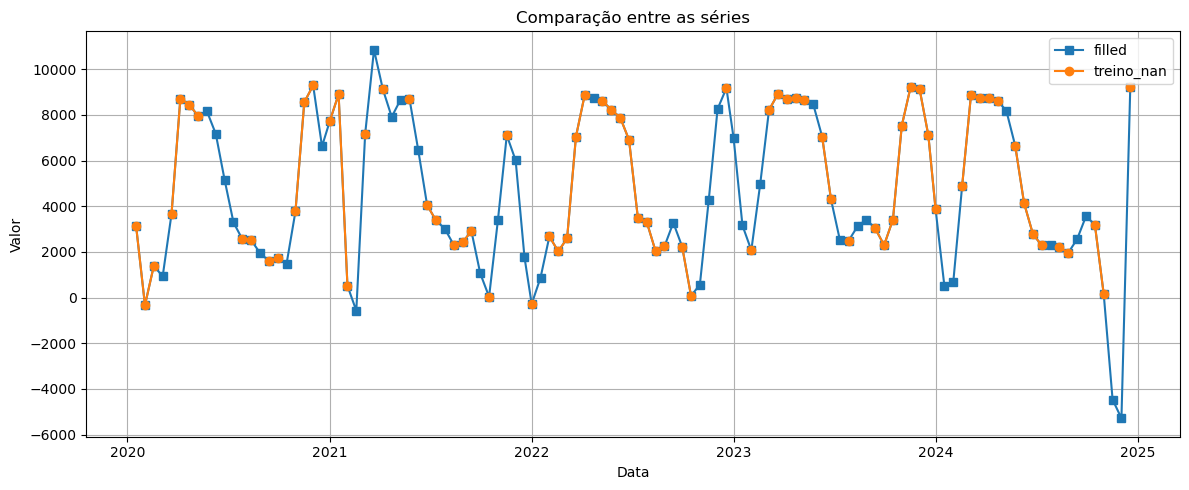

In [27]:
serie_filled = treino_nan.interpolate(method="polynomial", order=5)

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

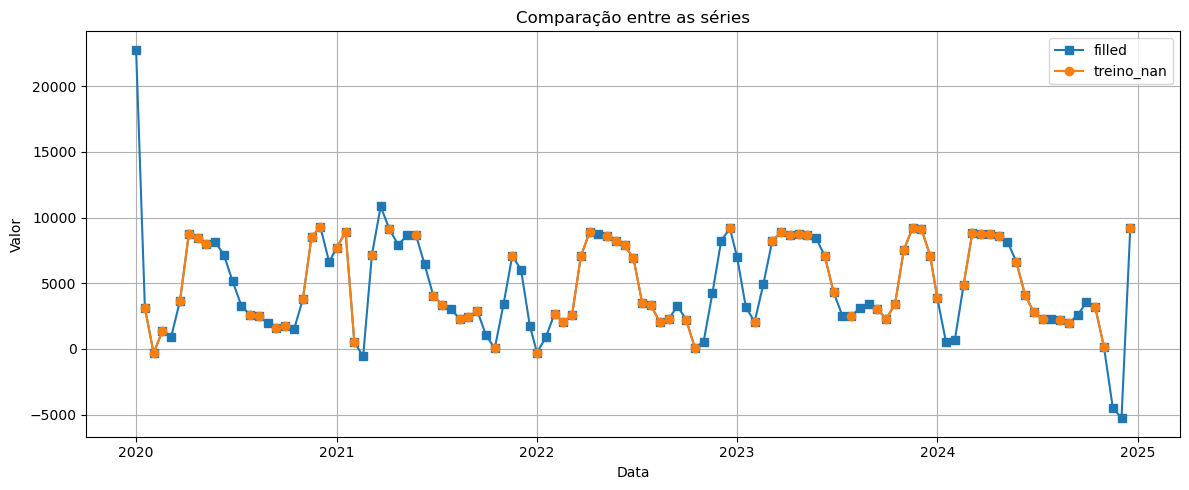

In [28]:
x = np.arange(len(serie_filled))
mask = ~serie_filled.isna()

cs = CubicSpline(x[mask], serie_filled[mask])

serie_filled[~mask] = cs(x[~mask])

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

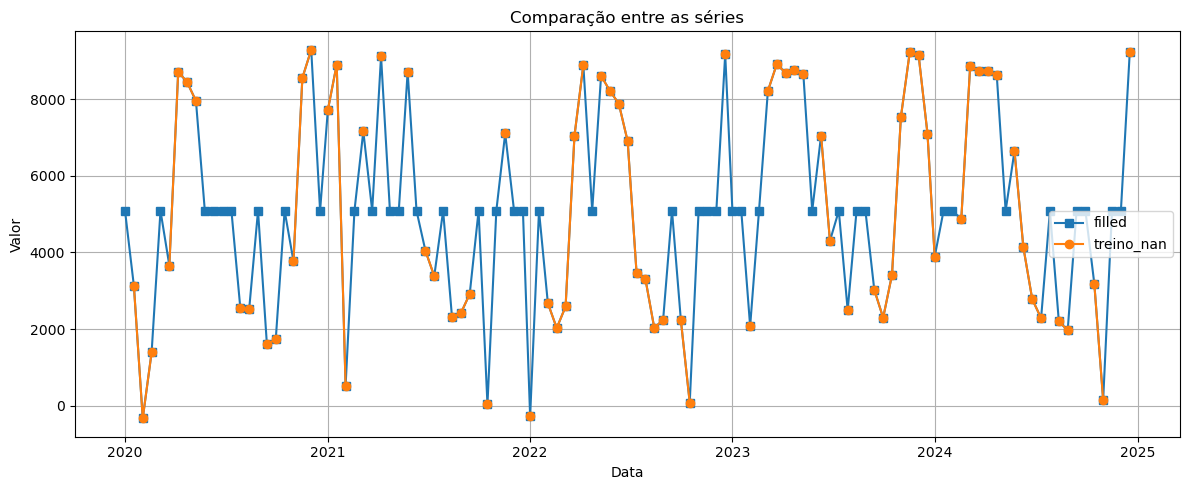

In [29]:
imputer = KNNImputer(n_neighbors=3)

serie_filled = pd.Series(
    imputer.fit_transform(treino_nan.values.reshape(-1, 1)).ravel(),
    index=treino_nan.index
)

plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

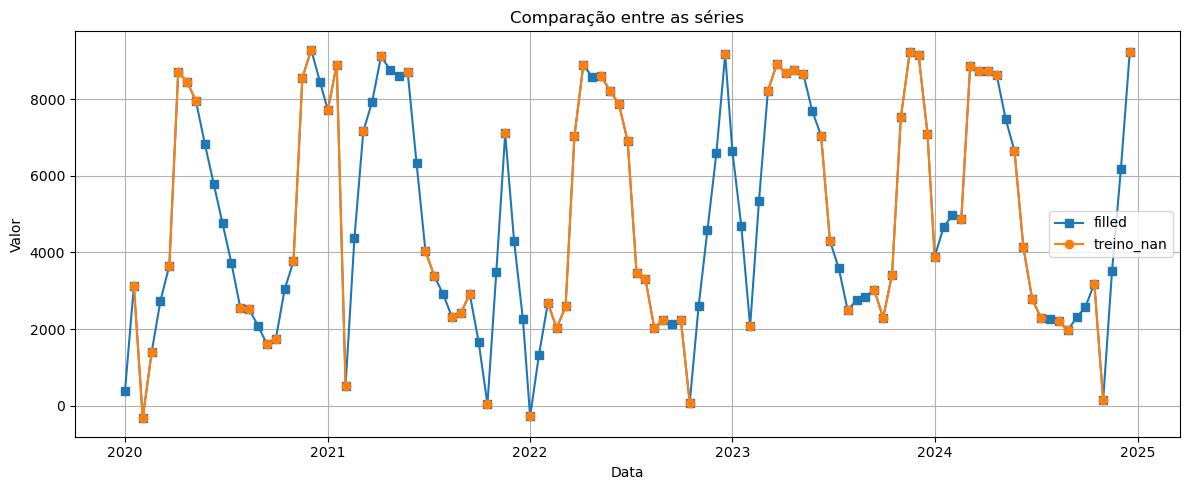

In [30]:
model = UnobservedComponents(
    treino_nan,
    level="local linear trend"
)

result = model.fit(disp=False)

serie_filled = treino_nan.copy()
serie_filled[serie_filled.isna()] = result.smoothed_state[0][serie_filled.isna()]


plt.figure(figsize=(12, 5))

plt.plot(serie_filled.index, serie_filled.values, label="filled", marker="s")
plt.plot(treino_nan.index, treino_nan.values, label="treino_nan", marker="o")

plt.xlabel("Data")
plt.ylabel("Valor")
plt.title("Comparação entre as séries")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Previsão

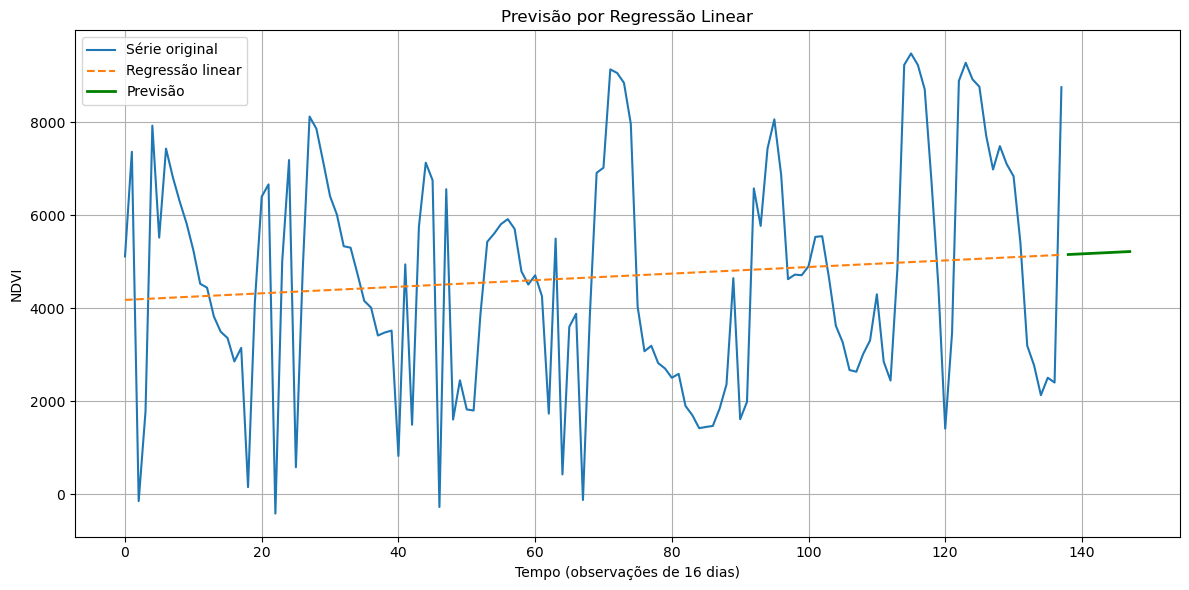

In [75]:
y = np.array(ts.NDVI)

x = np.arange(len(y)).reshape(-1, 1)

model = LinearRegression()
model.fit(x, y)

y_fit = model.predict(x)

forecast_steps = 10
x_future = np.arange(len(y), len(y) + forecast_steps).reshape(-1, 1)
y_forecast = model.predict(x_future)

plt.figure(figsize=(12, 6))

plt.plot(x.ravel(), y, label="Série original")
plt.plot(x.ravel(), y_fit, "--", label="Regressão linear")

plt.plot(
    x_future.ravel(),
    y_forecast,
    color="green",
    linewidth=2,
    label="Previsão"
)

plt.xlabel("Tempo (observações de 16 dias)")
plt.ylabel("NDVI")
plt.title("Previsão por Regressão Linear")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
serie = pd.Series(
    data=ts.NDVI,
    index=pd.to_datetime(ts.timeline),
    name="NDVI"
).sort_index()

serie = serie.asfreq("16D")
serie

2020-01-01    5112.0
2020-01-17    7360.0
2020-02-02    -145.0
2020-02-18    1783.0
2020-03-05    7922.0
               ...  
2025-10-13       NaN
2025-10-29       NaN
2025-11-14       NaN
2025-11-30       NaN
2025-12-16       NaN
Freq: 16D, Name: NDVI, Length: 137, dtype: float64

In [77]:
serie = pd.Series(
    data=ts.NDVI,
    index=pd.to_datetime(ts.timeline),
    name="NDVI"
).sort_index()

serie

2020-01-01    5112
2020-01-17    7360
2020-02-02    -145
2020-02-18    1783
2020-03-05    7922
              ... 
2025-10-16    2772
2025-11-01    2130
2025-11-17    2506
2025-12-03    2402
2025-12-19    8748
Name: NDVI, Length: 138, dtype: int64

In [78]:
print(ts.NDVI)

[5112, 7360, -145, 1783, 7922, 5516, 7428, 6813, 6292, 5824, 5245, 4524, 4441, 3822, 3494, 3359, 2856, 3147, 155, 4133, 6396, 6660, -413, 5005, 7183, 582, 4815, 8117, 7856, 7142, 6405, 6011, 5331, 5300, 4742, 4157, 4012, 3413, 3477, 3519, 825, 4941, 1495, 5754, 7126, 6749, -272, 6556, 1607, 2450, 1824, 1802, 3868, 5427, 5601, 5805, 5913, 5703, 4790, 4508, 4707, 4259, 1734, 5495, 429, 3599, 3880, -121, 3819, 6908, 7018, 9130, 9054, 8840, 7961, 4031, 3074, 3192, 2821, 2705, 2505, 2589, 1900, 1702, 1422, 1448, 1470, 1845, 2362, 4645, 1614, 1988, 6574, 5768, 7427, 8057, 6860, 4624, 4721, 4708, 4901, 5532, 5546, 4646, 3622, 3266, 2671, 2635, 3017, 3305, 4298, 2851, 2445, 4835, 9227, 9473, 9225, 8702, 6708, 4474, 1411, 3469, 8884, 9273, 8915, 8758, 7701, 6980, 7482, 7094, 6834, 5406, 3194, 2772, 2130, 2506, 2402, 8748]


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -131.586
Date:                Wed, 05 Aug 2026   AIC                            269.171
Time:                        12:16:09   BIC                            276.987
Sample:                             0   HQIC                           272.334
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2137      0.167     -1.276      0.202      -0.542       0.114
ar.L1          0.4578      0.087      5.268      0.000       0.287       0.628
sigma2         0.8118      0.123      6.624      0.0

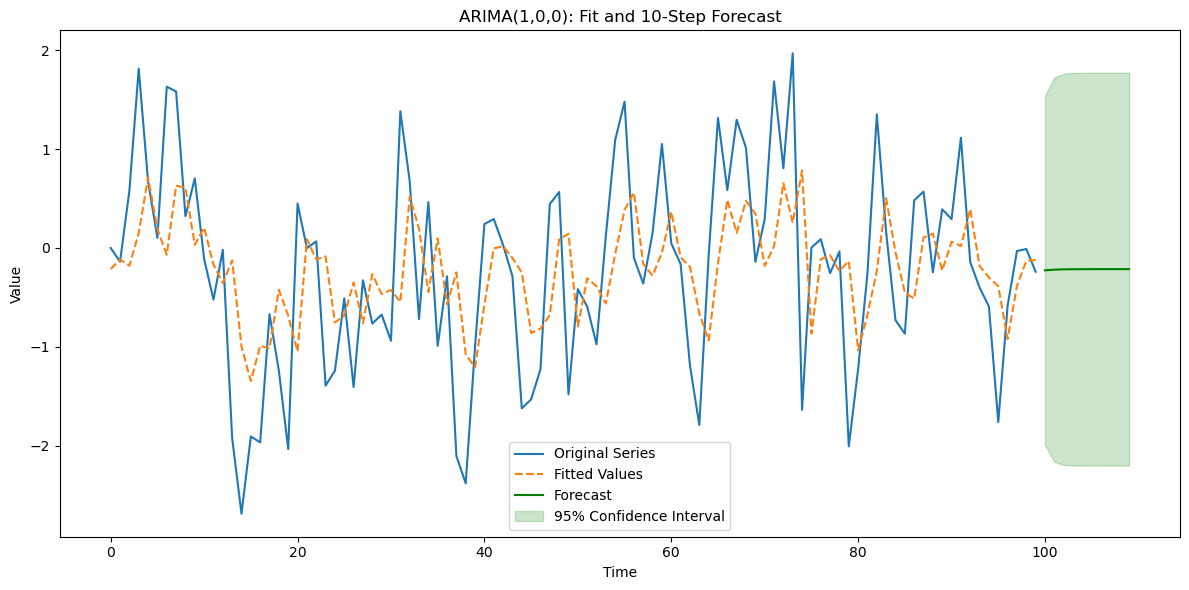

In [86]:
# 1. Simulate AR(1) time series
np.random.seed(42)
n = 100
e = np.random.normal(0, 1, n)
y = np.zeros(n)
for t in range(1, n):
   y[t] = 0.5 * y[t-1] + e[t]

# 2. Fit ARIMA(1,0,0)
model = ARIMA(y, order=(1, 0, 0))
fit = model.fit()
print(fit.summary())

# 3. Forecast next 10 steps
forecast_steps = 10
forecast_result = fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# 4. Plot
plt.figure(figsize=(12, 6))
plt.plot(y, label="Original Series")
plt.plot(fit.fittedvalues, label="Fitted Values", linestyle='--')

# Forecast line
forecast_index = np.arange(len(y), len(y) + forecast_steps)
plt.plot(forecast_index, forecast_mean, label="Forecast", color='green')

# Confidence interval shading
plt.fill_between(forecast_index,
                forecast_ci[:, 0],
                forecast_ci[:, 1],
                color='green', alpha=0.2, label="95% Confidence Interval")

plt.title("ARIMA(1,0,0): Fit and 10-Step Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
len(ts.NDVI)

138

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  138
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1251.086
Date:                Wed, 05 Aug 2026   AIC                           2508.172
Time:                        12:13:44   BIC                           2516.954
Sample:                             0   HQIC                          2511.741
                                - 138                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4662.0652    379.697     12.278      0.000    3917.873    5406.258
ar.L1          0.5149      0.087      5.892      0.000       0.344       0.686
sigma2      4.406e+06   5.44e+05      8.101      0.0

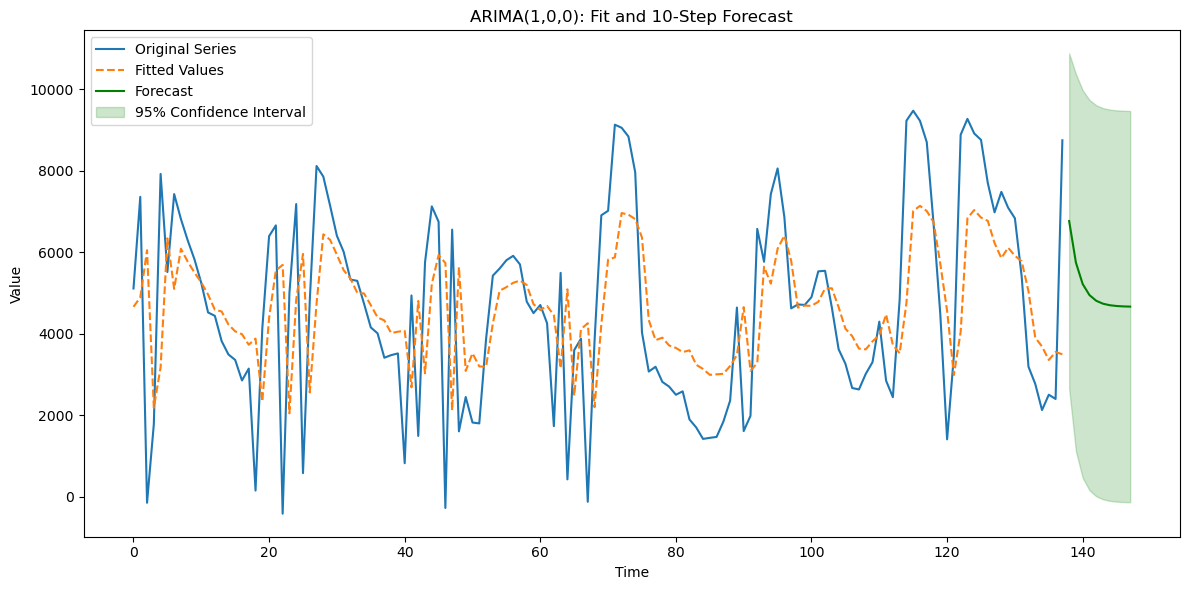

In [82]:
model = ARIMA(ts.NDVI, order=(1, 0, 0))
fit = model.fit()
print(fit.summary())

forecast_result = fit.get_forecast(steps=10)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()


plt.figure(figsize=(12, 6))
plt.plot(ts.NDVI, label="Original Series")
plt.plot(fit.fittedvalues, label="Fitted Values", linestyle='--')

forecast_index = np.arange(len(ts.NDVI), len(ts.NDVI) + forecast_steps)
plt.plot(forecast_index, forecast_mean, label="Forecast", color='green')

plt.fill_between(forecast_index,
                forecast_ci[:, 0],
                forecast_ci[:, 1],
                color='green', alpha=0.2, label="95% Confidence Interval")

plt.title("ARIMA(1,0,0): Fit and 10-Step Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.17887D+00    |proj g|=  4.38975D-02

At iterate    5    f=  9.17661D+00    |proj g|=  1.03669D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      7      9      1     0     0   8.250D-06   9.177D+00
  F =   9.1765350001801274     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                                      SARIMAX Results                                       
Dep. Variable:                         

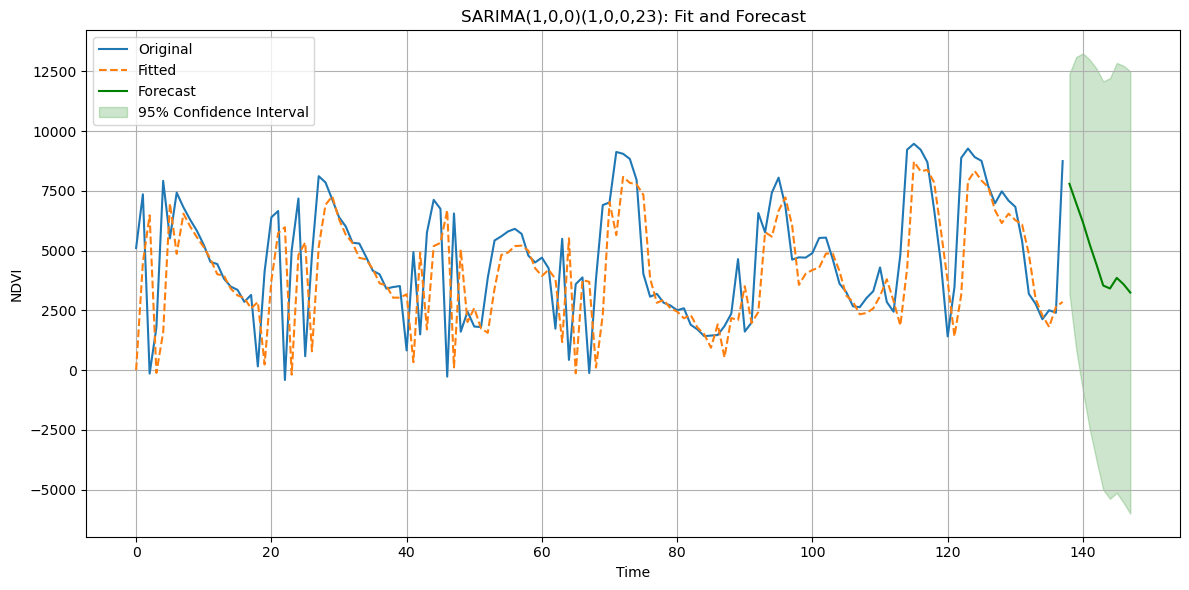

In [88]:
model = SARIMAX(
    ts.NDVI,
    order=(1,0,0),
    seasonal_order=(0,0,1,23)
)

fit = model.fit()

print(fit.summary())

forecast_steps = 10

forecast_result = fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

forecast_index = np.arange(
    len(ts.NDVI),
    len(ts.NDVI) + forecast_steps
)

plt.figure(figsize=(12,6))

plt.plot(
    np.arange(len(ts.NDVI)),
    ts.NDVI,
    label="Original"
)

plt.plot(
    np.arange(len(fit.fittedvalues)),
    fit.fittedvalues,
    "--",
    label="Fitted"
)

plt.plot(
    forecast_index,
    forecast_mean,
    color="green",
    label="Forecast"
)

plt.fill_between(
    forecast_index,
    np.array(forecast_ci)[:,0],
    np.array(forecast_ci)[:,1],
    color="green",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA(1,0,0)(1,0,0,23): Fit and Forecast")
plt.xlabel("Time")
plt.ylabel("NDVI")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [87]:
model = auto_arima(
    ts.NDVI,
    seasonal=True,
    m=23,
    trace=True,          # mostra os modelos testados
    stepwise=True,
    suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[23] intercept   : AIC=2514.903, Time=3.12 sec
 ARIMA(0,0,0)(0,0,0)[23] intercept   : AIC=2548.081, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[23] intercept   : AIC=2508.299, Time=2.19 sec
 ARIMA(0,0,1)(0,0,1)[23] intercept   : AIC=2519.439, Time=0.90 sec
 ARIMA(0,0,0)(0,0,0)[23]             : AIC=2758.408, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[23] intercept   : AIC=2508.166, Time=0.09 sec
 ARIMA(1,0,0)(0,0,1)[23] intercept   : AIC=2508.066, Time=0.61 sec
 ARIMA(1,0,0)(1,0,1)[23] intercept   : AIC=2509.982, Time=1.50 sec
 ARIMA(1,0,0)(0,0,2)[23] intercept   : AIC=2510.059, Time=7.60 sec
 ARIMA(1,0,0)(1,0,2)[23] intercept   : AIC=2511.973, Time=9.80 sec
 ARIMA(0,0,0)(0,0,1)[23] intercept   : AIC=2544.579, Time=0.50 sec
 ARIMA(2,0,0)(0,0,1)[23] intercept   : AIC=2508.890, Time=0.89 sec
 ARIMA(1,0,1)(0,0,1)[23] intercept   : AIC=2508.972, Time=0.91 sec
 ARIMA(2,0,1)(0,0,1)[23] intercept   : AIC=2510.794, Time=1.30 sec
 ARIMA(1,0,0)(0,0,1

## STL

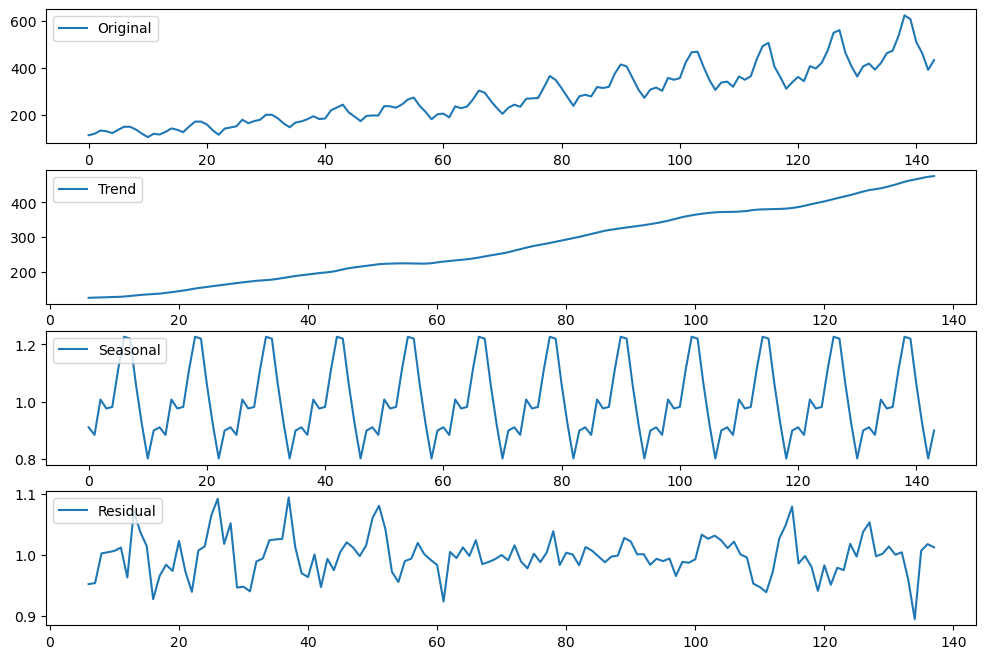

In [89]:
# Load dataset
data = sm.datasets.get_rdataset('AirPassengers').data
data['time'] = pd.date_range(start='1949-01', periods=len(data), freq='M')

# Decompose the time series multiplicatively
decomposition = sm.tsa.seasonal_decompose(data['value'], model='multiplicative', period=12)

# Plotting the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
ax1.plot(data['value'], label='Original')
ax1.legend(loc='upper left')
ax2.plot(decomposition.trend, label='Trend')
ax2.legend(loc='upper left')
ax3.plot(decomposition.seasonal, label='Seasonal')
ax3.legend(loc='upper left')
ax4.plot(decomposition.resid, label='Residual')
ax4.legend(loc='upper left')
plt.show()


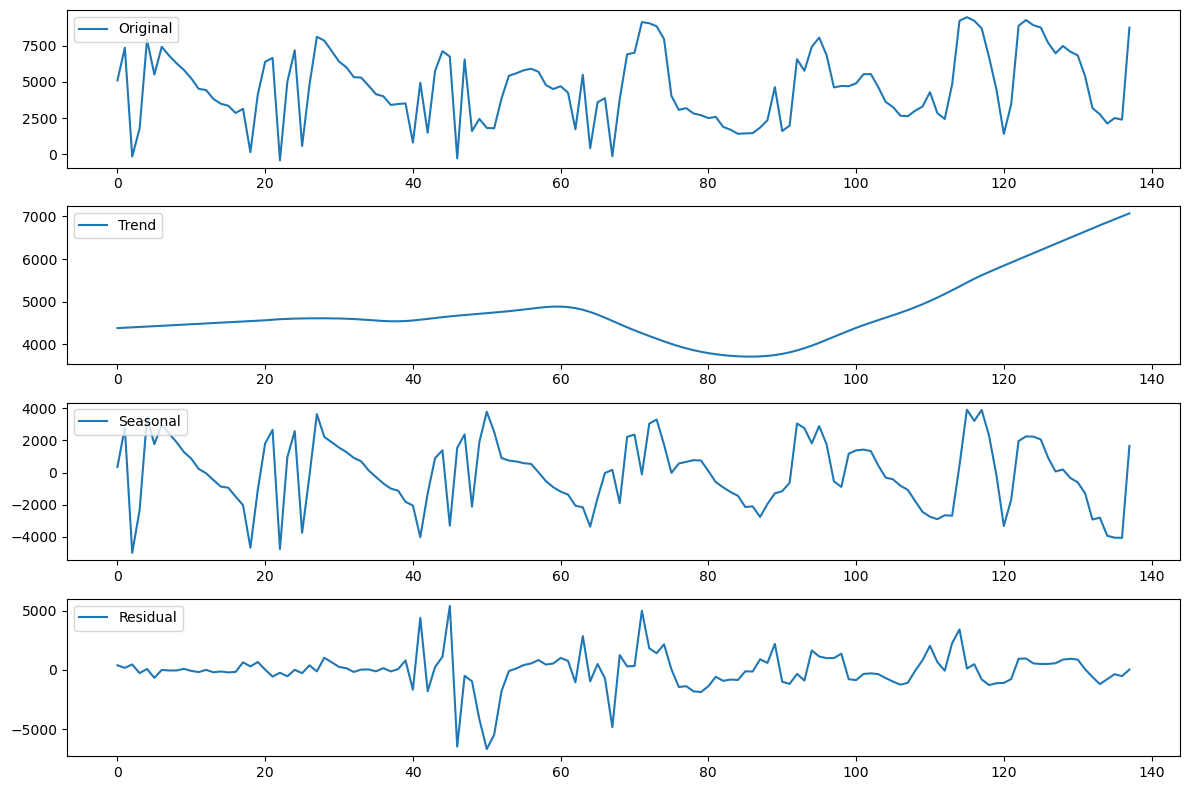

In [41]:
decomposition = STL(
    ts.NDVI,
    period=23,
    robust=True
).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))

ax1.plot(ts.NDVI, label='Original')
ax1.legend(loc='upper left')

ax2.plot(decomposition.trend, label='Trend')
ax2.legend(loc='upper left')

ax3.plot(decomposition.seasonal, label='Seasonal')
ax3.legend(loc='upper left')

ax4.plot(decomposition.resid, label='Residual')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

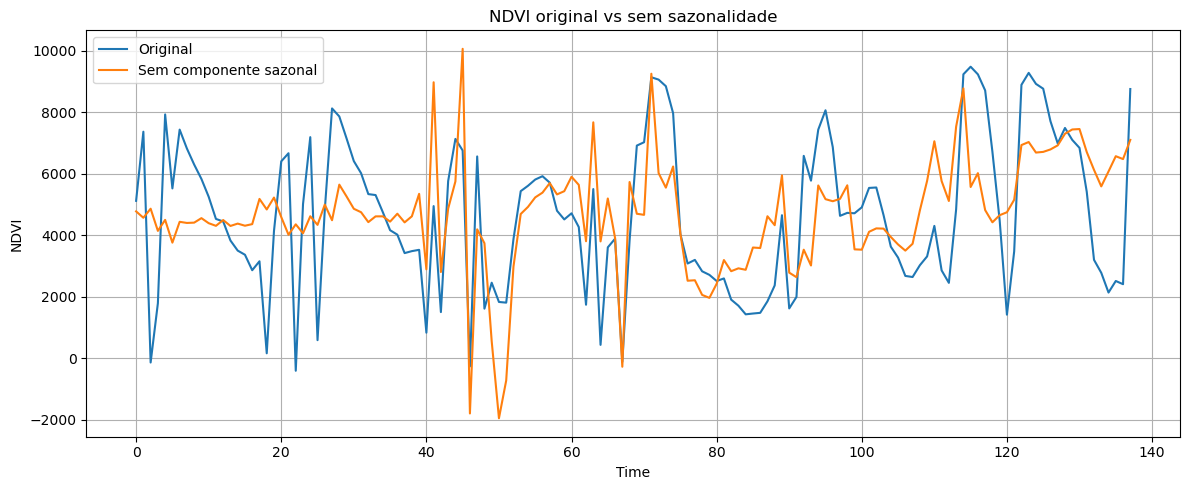

In [42]:
serie_sem_sazonal = ts.NDVI - decomposition.seasonal

plt.figure(figsize=(12,5))

plt.plot(ts.NDVI, label="Original")
plt.plot(serie_sem_sazonal, label="Sem componente sazonal")

plt.xlabel("Time")
plt.ylabel("NDVI")
plt.title("NDVI original vs sem sazonalidade")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

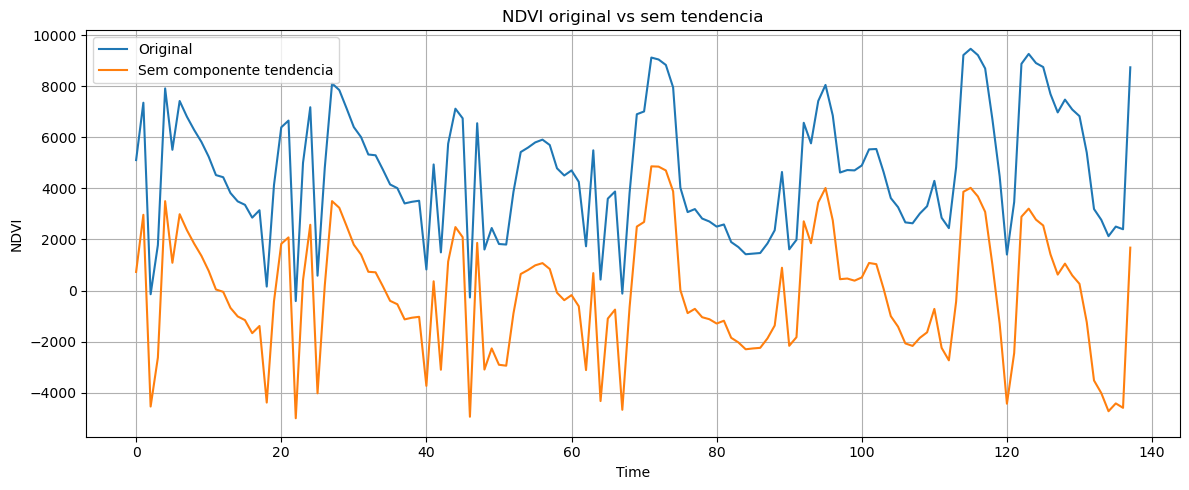

In [43]:
serie_sem_tendencia = ts.NDVI - decomposition.trend

plt.figure(figsize=(12,5))

plt.plot(ts.NDVI, label="Original")
plt.plot(serie_sem_tendencia, label="Sem componente tendencia")

plt.xlabel("Time")
plt.ylabel("NDVI")
plt.title("NDVI original vs sem tendencia")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

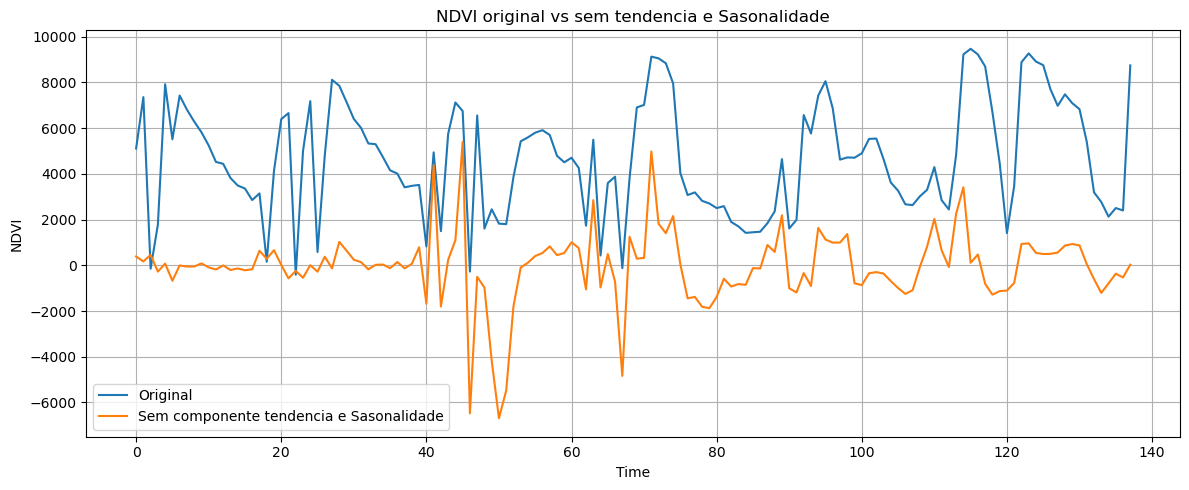

In [44]:
serie_sem_tendencia_e_saso = ts.NDVI - decomposition.trend - decomposition.seasonal

plt.figure(figsize=(12,5))

plt.plot(ts.NDVI, label="Original")
plt.plot(serie_sem_tendencia_e_saso, label="Sem componente tendencia e Sasonalidade")

plt.xlabel("Time")
plt.ylabel("NDVI")
plt.title("NDVI original vs sem tendencia e Sasonalidade")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
gdf

,class,geometry,ts
0,agua,POINT (-45.64765 -20.70176),2020-01-01 -5941 2020-01-17 -1284 2020-02-...
1,agua,POINT (-45.65449 -20.70993),2020-01-01 198 2020-01-17 -2867 2020-02-...
2,agua,POINT (-45.67474 -20.72049),2020-01-01 -1409 2020-01-17 -204 2020-02-...
3,agua,POINT (-45.63813 -20.68722),2020-01-01 17 2020-01-17 877 2020-02-...
4,agua,POINT (-45.62348 -20.70872),2020-01-01 -7287 2020-01-17 -7128 2020-02-...
5,agua,POINT (-45.67213 -20.69659),2020-01-01 -473 2020-01-17 171 2020-02-...
6,agua,POINT (-45.59474 -20.68904),2020-01-01 -6007 2020-01-17 -5940 2020-02-...
7,agua,POINT (-45.65632 -20.7319),2020-01-01 6640 2020-01-17 2263 2020-02-...
8,agua,POINT (-45.69606 -20.71637),2020-01-01 896 2020-01-17 -8352 2020-02-...
9,agua,POINT (-45.69577 -20.73681),2020-01-01 -2107 2020-01-17 -2520 2020-02-...


In [90]:
X = pd.DataFrame(
    gdf["ts"].tolist(),
    index=gdf.index
)

y = gdf["class"]

In [91]:
X.shape

(30, 138)

In [92]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
y_pred = clf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        agua       1.00      1.00      1.00         3
    floresta       1.00      1.00      1.00         2
        pivo       1.00      1.00      1.00         3
        solo       1.00      1.00      1.00         1

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Confusion Matrix:
[[3 0 0 0]
 [0 2 0 0]
 [0 0 3 0]
 [0 0 0 1]]
